In [1]:
%%html
<style>
.question{ 
    background: #99ffff;
    border: solid 1px #1356ff;
    border-radius: 3px;
    padding: 2px;
}
.question>code {background: #e8ffff;border: solid 1px #83aab7;}
.warning {background: #ffadad;}
.Q{font-weight: bold;}
</style>

### Rules
1. <font class="warning">Run above cell, and do not change its content</font>
2. The questions that you need to solve will have a <font class="question">blue background</font>, you only need to change the part that says `## TODO: Complete Code ##` inside code cells
3. Don't forget to run every cell before going to the next one

<hr />

# Vehicle

Dataset documentation: https://www.fueleconomy.gov/feg/ws/index.shtml#vehicle

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
pd.set_option('display.max_columns', None)

<div class="question">Q1. Read the file <code>vehicles.csv</code> into a pandas dataframe</div>

In [3]:
## TODO: Complete Code ##
df = pd.read_csv('vehicles.csv', encoding='utf-8-sig')

C:\Users\tagay\AppData\Local\Temp\ipykernel_17748\1250323581.py:1: DtypeWarning: Columns (0: fuelType2, 1: rangeA, 2: evMotor, 3: mfrCode, 4: c240Dscr, 5: c240bDscr, 6: startStop) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('vehicles.csv', encoding='utf-8-sig')


In [4]:
df.head(10)

,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,comb08U,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,drive,engId,eng_dscr,feScore,fuelCost08,fuelCostA08,fuelType,fuelType1,ghgScore,ghgScoreA,highway08,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,id,lv2,lv4,make,model,mpgData,phevBlended,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,trany,UCity,UCityA,UHighway,UHighwayA,VClass,year,youSaveSpend,guzzler,trans_dscr,tCharger,sCharger,atvType,fuelType2,rangeA,evMotor,mfrCode,c240Dscr,charge240b,c240bDscr,createdOn,modifiedOn,startStop,phevCity,phevHwy,phevComb
0,15.695714,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,423.190476,21,0.0,0,0.0,0.0,0.0,0.0,4.0,2.0,Rear-Wheel Drive,9011,(FFS),-1,1750,0,Regular,Regular Gasoline,-1,-1,25,0.0,0,0.0,0.0,0.0,0.0,0,0,1,0,0,Alfa Romeo,Spider Veloce 2000,Y,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,23.3333,0.0,35.0000,0.0,Two Seaters,1985,-2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
1,29.964545,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,12.0,4.9,Rear-Wheel Drive,22020,(GUZZLER),-1,3300,0,Regular,Regular Gasoline,-1,-1,14,0.0,0,0.0,0.0,0.0,0.0,0,0,10,0,0,Ferrari,Testarossa,N,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,11.0000,0.0,19.0000,0.0,Two Seaters,1985,-9750,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
2,12.207778,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,329.148148,27,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,Front-Wheel Drive,2100,(FFS),-1,1350,0,Regular,Regular Gasoline,-1,-1,33,0.0,0,0.0,0.0,0.0,0.0,19,77,100,0,0,Dodge,Charger,Y,False,0,0,0,0.0,0.0,0.0,0.0,Manual 5-spd,29.0000,0.0,47.0000,0.0,Subcompact Cars,1985,0,NaN,SIL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
3,29.964545,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,8.0,5.2,Rear-Wheel Drive,2850,NaN,-1,3300,0,Regular,Regular Gasoline,-1,-1,12,0.0,0,0.0,0.0,0.0,0.0,0,0,1000,0,0,Dodge,B150/B250 Wagon 2WD,N,False,0,0,0,0.0,0.0,0.0,0.0,Automatic 3-spd,12.2222,0.0,16.6667,0.0,Vans,1985,-9750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
4,17.347895,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,467.736842,19,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,4-Wheel or All-Wheel Drive,66031,"(FFS,TRBO)",-1,2450,0,Premium,Premium Gasoline,-1,-1,23,0.0,0,0.0,0.0,0.0,0.0,0,0,10000,0,14,Subaru,Legacy AWD Turbo,N,False,0,90,0,0.0,0.0,0.0,0.0,Manual 5-spd,21.0000,0.0,32.0000,0.0,Compact Cars,1993,-5500,NaN,NaN,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
5,14.982273,0.0,0.0,0.0,21,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,403.954545,22,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,Front-Wheel Drive,66020,(FFS),-1,1650,0,Regular,Regular Gasoline,-1,-1,24,0.0,0,0.0,0.0,0.0,0.0,0,0,10001,0,15,Subaru,Loyale,N,False,0,88,0,0.0,0.0,0.0,0.0,Automatic 3-spd,27.0000,0.0,33.0000,0.0,Compact Cars,1993,-1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
6,13.184400,0.0,0.0,0.0,22,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,355.480000,25,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,Front-Wheel Drive,66020,(FFS),-1,1450,0,Regular,Regular Gasoline,-1,-1,29,0.0,0,0.0,0.0,0.0,0.0,0,0,10002,0,15,Subaru,Loyale,Y,False,0,88,0,0.0,0.0,0.0,0.0,Manual 5-spd,28.0000,0.0,41.0000,0.0,Compact Cars,1993,-500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,Tue Jan 01 00:00:00 EST 2013,Tue Jan 01 00:00:00 EST 2013,NaN,0,0,0
7,13.733750,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,370.291667,24,0.0,0,0.0,0.0,0.0,0.0,4.0,1.6,Front-Wheel Drive,57005,(FFS),-1,1500,0,Regular,Regular Gasoline,-1,-1,26,0.0,0,0.0,0.0,0.0,0.0,0,0,10003,0,13,

<div class="question">Q2. There are too many columns, let's only focus about the following ones that are stored in the list <code>columns</code>, complete the code to filter <code>df</code> to contain only these columns.</div>

In [6]:
columns = ['make', 'model', 'year', 'barrels08', 'barrelsA08', 'charge120', 'charge240', 'city08', 'city08U', 'cityA08', 'cityA08U', 'cityCD', 'cityE', 'cityUF', 'co2', 'co2A', 'co2TailpipeAGpm', 'co2TailpipeGpm', 'comb08', 'comb08U', 'combA08', 'combA08U', 'combE', 'combinedCD', 'combinedUF', 'cylinders', 'displ', 'feScore', 'fuelCost08', 'fuelCostA08', 'ghgScore', 'ghgScoreA', 'highway08', 'highway08U', 'highwayA08', 'highwayA08U', 'highwayCD', 'highwayE', 'highwayUF', 'hlv', 'hpv', 'lv2', 'lv4', 'pv2', 'pv4', 'range', 'rangeCity', 'rangeCityA', 'rangeHwy', 'rangeHwyA', 'UCity', 'UCityA', 'UHighway', 'UHighwayA', 'youSaveSpend']

In [7]:
## TODO: Complete Code ##
df = df[columns]

In [8]:
df.head(10)

,make,model,year,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,comb08U,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,feScore,fuelCost08,fuelCostA08,ghgScore,ghgScoreA,highway08,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,lv2,lv4,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,UCity,UCityA,UHighway,UHighwayA,youSaveSpend
0,Alfa Romeo,Spider Veloce 2000,1985,15.695714,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,423.190476,21,0.0,0,0.0,0.0,0.0,0.0,4.0,2.0,-1,1750,0,-1,-1,25,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,23.3333,0.0,35.0000,0.0,-2000
1,Ferrari,Testarossa,1985,29.964545,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,12.0,4.9,-1,3300,0,-1,-1,14,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,11.0000,0.0,19.0000,0.0,-9750
2,Dodge,Charger,1985,12.207778,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,329.148148,27,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,-1,1350,0,-1,-1,33,0.0,0,0.0,0.0,0.0,0.0,19,77,0,0,0,0,0,0.0,0.0,0.0,0.0,29.0000,0.0,47.0000,0.0,0
3,Dodge,B150/B250 Wagon 2WD,1985,29.964545,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,8.0,5.2,-1,3300,0,-1,-1,12,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,12.2222,0.0,16.6667,0.0,-9750
4,Subaru,Legacy AWD Turbo,1993,17.347895,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,467.736842,19,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,-1,2450,0,-1,-1,23,0.0,0,0.0,0.0,0.0,0.0,0,0,0,14,0,90,0,0.0,0.0,0.0,0.0,21.0000,0.0,32.0000,0.0,-5500
5,Subaru,Loyale,1993,14.982273,0.0,0.0,0.0,21,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,403.954545,22,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,-1,1650,0,-1,-1,24,0.0,0,0.0,0.0,0.0,0.0,0,0,0,15,0,88,0,0.0,0.0,0.0,0.0,27.0000,0.0,33.0000,0.0,-1500
6,Subaru,Loyale,1993,13.184400,0.0,0.0,0.0,22,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,355.480000,25,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,-1,1450,0,-1,-1,29,0.0,0,0.0,0.0,0.0,0.0,0,0,0,15,0,88,0,0.0,0.0,0.0,0.0,28.0000,0.0,41.0000,0.0,-500
7,Toyota,Corolla,1993,13.733750,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,370.291667,24,0.0,0,0.0,0.0,0.0,0.0,4.0,1.6,-1,1500,0,-1,-1,26,0.0,0,0.0,0.0,0.0,0.0,0,0,0,13,0,89,0,0.0,0.0,0.0,0.0,29.0000,0.0,37.0000,0.0,-750
8,Toyota,Corolla,1993,12.677308,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,341.807692,26,0.0,0,0.0,0.0,0.0,0.0,4.0,1.6,-1,1400,0,-1,-1,31,0.0,0,0.0,0.0,0.0,0.0,0,0,0,13,0,89,0,0.0,0.0,0.0,0.0,30.0000,0.0,43.0000,0.0,-250
9,Toyota,Corolla,1993,13.184400,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,355.480000,25,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,-1,1450,0,-1,-1,30,0.0,0,0.0,0.0,0.0,0.0,0,0,0,13,0,89,0,0.0,0.0,0.0,0.0,29.0000,0.0,42.0000,0.0,-500


<b>Note:</b> `fillna` is a `pandas` function that replaces or the `null` values with some specific passed value. `KMeans` doesn't accept any null values in the dataset.

In [9]:
df = df.fillna(0)

<div class="question">Q3. First two columns cannot be part of the training set because they're not numerical, and we don't want to include the <code>years</code> column. Create a new variable <code>data</code> that excludes the first 3 columns</div>

In [10]:
## TODO: Complete Code ##
data = df.drop(df.columns[:3], axis=1)

<div class="question">Q4. Using the Elbow method, run KMeans on <code>data</code> for all K (number of clusters) values between 1 and 15, plot the SSE error for every K</div>

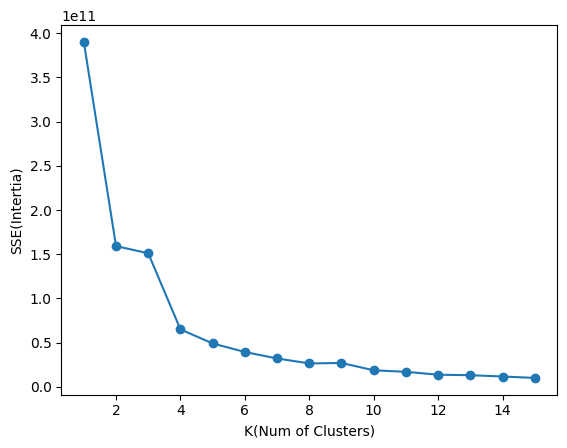

In [11]:
err = []
for i in range(1,16):
    ## TODO: Complete Code ##
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(data)
    err.append(kmeans.inertia_)

err = np.asarray(err)
## TODO: Complete Code ##
plt.plot(range(1,16), err, marker='o')
plt.xlabel('K(Num of Clusters)')
plt.ylabel('SSE(Intertia)')
plt.show()

<div class="question">Q5. Run KMeans for 3 clusters on <code>data</code></div>

In [12]:
## TODO: Complete Code ##
kmeans = KMeans(n_clusters=3).fit(data)

<div class="question">Q6. Add a new column to the original dataset <code>data</code> that is called <code>label</code> and that contains the label of each row as per the previous kmeans clustering.</div>

In [13]:
##df['label'] =  TODO: Complete Code ##
df['label'] = kmeans.labels_

In [14]:
df.head(10)

,make,model,year,barrels08,barrelsA08,charge120,charge240,city08,city08U,cityA08,cityA08U,cityCD,cityE,cityUF,co2,co2A,co2TailpipeAGpm,co2TailpipeGpm,comb08,comb08U,combA08,combA08U,combE,combinedCD,combinedUF,cylinders,displ,feScore,fuelCost08,fuelCostA08,ghgScore,ghgScoreA,highway08,highway08U,highwayA08,highwayA08U,highwayCD,highwayE,highwayUF,hlv,hpv,lv2,lv4,pv2,pv4,range,rangeCity,rangeCityA,rangeHwy,rangeHwyA,UCity,UCityA,UHighway,UHighwayA,youSaveSpend,label
0,Alfa Romeo,Spider Veloce 2000,1985,15.695714,0.0,0.0,0.0,19,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,423.190476,21,0.0,0,0.0,0.0,0.0,0.0,4.0,2.0,-1,1750,0,-1,-1,25,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,23.3333,0.0,35.0000,0.0,-2000,0
1,Ferrari,Testarossa,1985,29.964545,0.0,0.0,0.0,9,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,12.0,4.9,-1,3300,0,-1,-1,14,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,11.0000,0.0,19.0000,0.0,-9750,1
2,Dodge,Charger,1985,12.207778,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,329.148148,27,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,-1,1350,0,-1,-1,33,0.0,0,0.0,0.0,0.0,0.0,19,77,0,0,0,0,0,0.0,0.0,0.0,0.0,29.0000,0.0,47.0000,0.0,0,0
3,Dodge,B150/B250 Wagon 2WD,1985,29.964545,0.0,0.0,0.0,10,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,807.909091,11,0.0,0,0.0,0.0,0.0,0.0,8.0,5.2,-1,3300,0,-1,-1,12,0.0,0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,12.2222,0.0,16.6667,0.0,-9750,1
4,Subaru,Legacy AWD Turbo,1993,17.347895,0.0,0.0,0.0,17,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,467.736842,19,0.0,0,0.0,0.0,0.0,0.0,4.0,2.2,-1,2450,0,-1,-1,23,0.0,0,0.0,0.0,0.0,0.0,0,0,0,14,0,90,0,0.0,0.0,0.0,0.0,21.0000,0.0,32.0000,0.0,-5500,2
5,Subaru,Loyale,1993,14.982273,0.0,0.0,0.0,21,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,403.954545,22,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,-1,1650,0,-1,-1,24,0.0,0,0.0,0.0,0.0,0.0,0,0,0,15,0,88,0,0.0,0.0,0.0,0.0,27.0000,0.0,33.0000,0.0,-1500,0
6,Subaru,Loyale,1993,13.184400,0.0,0.0,0.0,22,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,355.480000,25,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,-1,1450,0,-1,-1,29,0.0,0,0.0,0.0,0.0,0.0,0,0,0,15,0,88,0,0.0,0.0,0.0,0.0,28.0000,0.0,41.0000,0.0,-500,0
7,Toyota,Corolla,1993,13.733750,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,370.291667,24,0.0,0,0.0,0.0,0.0,0.0,4.0,1.6,-1,1500,0,-1,-1,26,0.0,0,0.0,0.0,0.0,0.0,0,0,0,13,0,89,0,0.0,0.0,0.0,0.0,29.0000,0.0,37.0000,0.0,-750,0
8,Toyota,Corolla,1993,12.677308,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,341.807692,26,0.0,0,0.0,0.0,0.0,0.0,4.0,1.6,-1,1400,0,-1,-1,31,0.0,0,0.0,0.0,0.0,0.0,0,0,0,13,0,89,0,0.0,0.0,0.0,0.0,30.0000,0.0,43.0000,0.0,-250,0
9,Toyota,Corolla,1993,13.184400,0.0,0.0,0.0,23,0.0,0,0.0,0.0,0.0,0.0,-1,-1,0.0,355.480000,25,0.0,0,0.0,0.0,0.0,0.0,4.0,1.8,-1,1450,0,-1,-1,30,0.0,0,0.0,0.0,0.0,0.0,0,0,0,13,0,89,0,0.0,0.0,0.0,0.0,29.0000,0.0,42.0000,0.0,-500,0


<div class="question">Q6. Using a count plot, show how many rows there are for every label in the dataset</div>

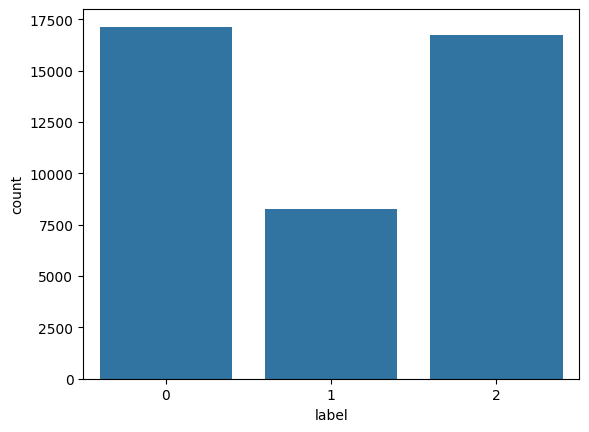

In [15]:
## TODO: Complete Code ##
sns.countplot(data=df, x='label')
plt.show()

<div class="question">Q7. Show the KDE distribution for the column <code>year</code>, show a different plot for every different label</div>

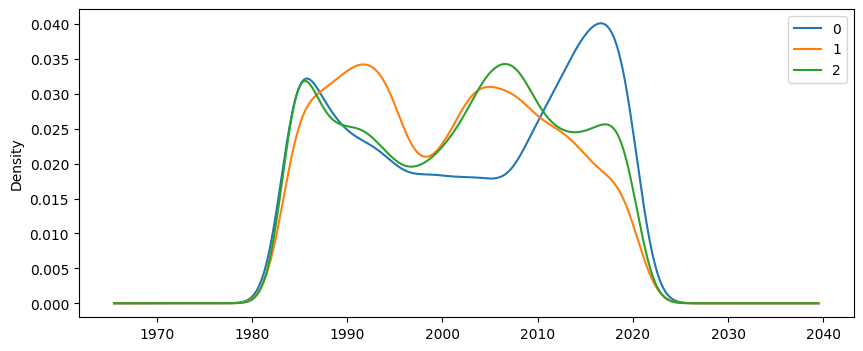

In [16]:
## TODO: Complete Code ##
df.groupby('label')['year'].plot(kind='density', legend=True, figsize=(10,4))
plt.show()

<div class="question">Q8. Show how many Toyota cars there are for every different label using a Count Plot</div>

In [17]:
##toyota = TODO: Complete Code ##
toyota = df[df['make'] == 'Toyota']

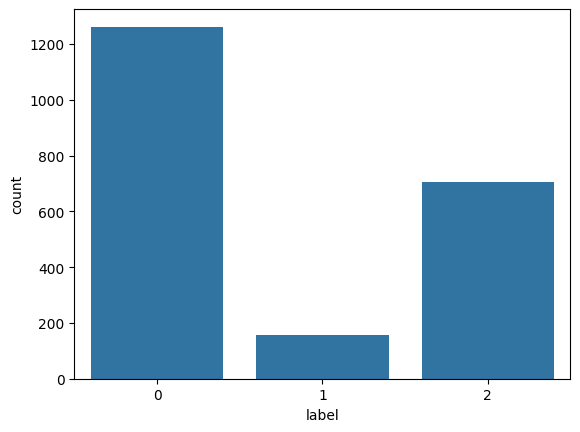

In [18]:
## TODO: Complete Code ##
sns.countplot(data=toyota, x='label')
plt.show()

<div class="question">Q9. Show in a Scatter plot the relation between <code>year</code> and <code>cylinders</code> columns, differ between every label using a different color for each of them.</div>

Hint: pass the values `palette="Set1"` and `marker="+"` for a better visualization.

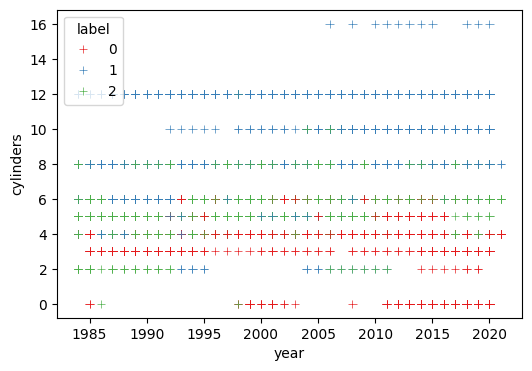

In [19]:
plt.figure(figsize=(6,4))
## TODO: Complete Code ##
sns.scatterplot(data=df, x='year', y='cylinders', hue='label', palette="Set1", marker="+")
plt.show()

<div class="question">Q10. Generalize the previous code in this function to show the relation between any two columns</div>

In [22]:
def plot_result(kmeans, column1, column2):
    plt.figure(figsize=(6,4))
    ## TODO: Complete Code ##
    sns.scatterplot(data=df, x=column1, y=column2, hue='label', palette="Set1", marker="+")
    plt.show()

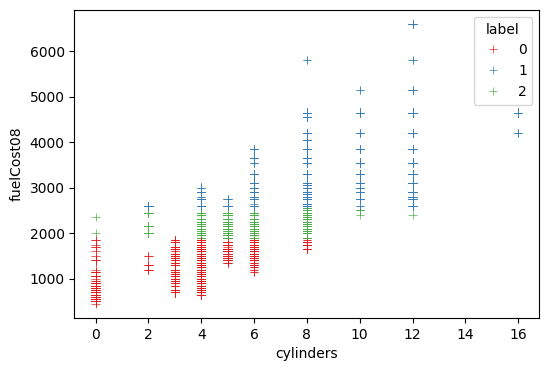

In [23]:
plot_result(kmeans, 'cylinders', 'fuelCost08')

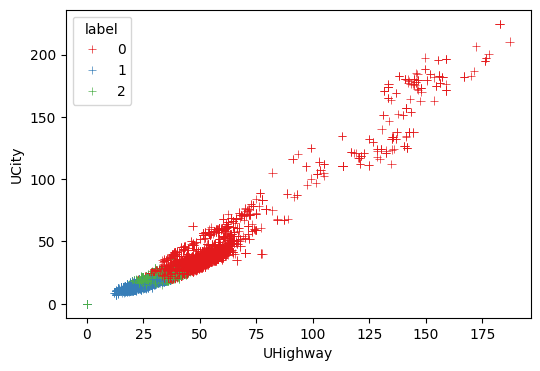

In [24]:
plot_result(kmeans, 'UHighway', 'UCity')